In [2]:
#importing libraries and reading files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
Ultracemco = pd.read_csv('Copy of Ultracemco.csv')
Nestle_india = pd.read_csv('Copy of NESTLEIND.csv')
Maruti = pd.read_csv('Copy of maruti.csv')

In [28]:
# Convert Date column to datetime and calculating average closing price yearly
Maruti['Date'] = pd.to_datetime(Maruti['Date'], format='%d-%m-%Y')
Maruti['Year'] = Maruti['Date'].dt.year
avg_yearly_close_Maruti = Maruti.groupby('Year')['Close'].mean()
Ultracemco['Date'] = pd.to_datetime(Ultracemco['Date'], format='%d-%m-%Y')
Ultracemco['Year'] = Ultracemco['Date'].dt.year
avg_yearly_close_Ultracemco = Ultracemco.groupby('Year')['Close'].mean()
Nestle_india['Date'] = pd.to_datetime(Maruti['Date'], format='%d-%m-%Y')
Maruti['Year'] = Maruti['Date'].dt.year
avg_yearly_close_Maruti = Maruti.groupby('Year')['Close'].mean()


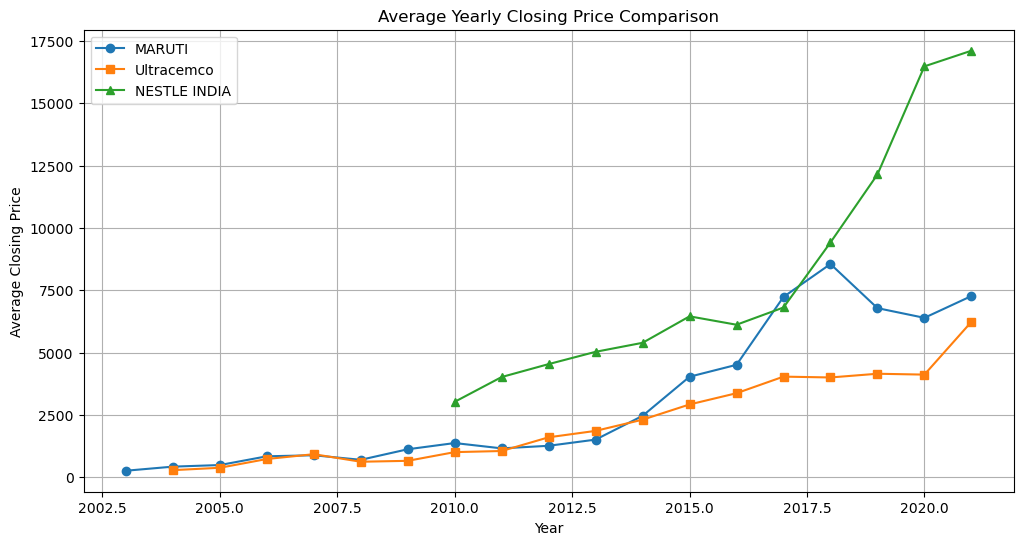

In [30]:
#plotting the average closing price yearly for Maruti
plt.figure(figsize=(12,6))

plt.plot(avg_yearly_close_Maruti.index,
         avg_yearly_close_Maruti.values,
         marker='o',
         label='MARUTI')

plt.plot(avg_yearly_close_Ultrasemco.index,
         avg_yearly_close_Ultrasemco.values,
         marker='s',
         label='Ultracemco')

plt.plot(avg_yearly_close_Nestle_india.index,
         avg_yearly_close_Nestle_india.values,
         marker='^',
         label='NESTLE INDIA')

plt.xlabel('Year')
plt.ylabel('Average Closing Price')
plt.title('Average Yearly Closing Price Comparison')

plt.legend()
plt.grid(True)
plt.show()


In [50]:
#volume and price Fluctuation
Maruti = Maruti.sort_values('Date').reset_index(drop=True)
Nestle_inida = Nestle_india.sort_values('Date').reset_index = True
Ultracemco = Ultracemco.sort_values('Date').reset_index(drop=True)
Maruti['Prev_Close'] = Maruti['Close'].shift(1)
Nestle_india['Prev_Close'] = Nestle_india['Close'].shift(1)
Ultracemco['Prev_Close'] = Ultracemco['Close'].shift(1)
Maruti['Price_Gap'] = Maruti['Open'] - Maruti['Prev_Close']
Maruti['Gap_Percent'] = (Maruti['Price_Gap'] / Maruti['Prev_Close']) * 100

Nestle_india['Price_Gap'] = Nestle_india['Open'] - Nestle_india['Prev_Close']
Nestle_india['Gap_Percent'] = (Nestle_india['Price_Gap'] / Nestle_india['Prev_Close']) * 100

Ultracemco['Price_Gap'] = Ultracemco['Open'] - Ultracemco['Prev_Close']
Ultracemco['Gap_Percent'] = (Ultracemco['Price_Gap'] / Ultracemco['Prev_Close']) * 100

#We’ll assume ±2% as a significant gap
gap_days_M = Maruti[Maruti['Gap_Percent'].abs() >= 2]
gap_days_N = Nestle_india[Nestle_india['Gap_Percent'].abs() >= 2]
gap_days_U = Ultracemco[Ultracemco['Gap_Percent'].abs() >= 2]


gap_day_M = gap_days_M[['Date', 'Prev_Close', 'Open', 'Price_Gap', 'Gap_Percent', 'Volume']]
gap_days_N = gap_days_N[['Date', 'Prev_Close', 'Open', 'Price_Gap', 'Gap_Percent', 'Volume']]
gap_days_U = gap_days_U[['Date', 'Prev_Close', 'Open', 'Price_Gap', 'Gap_Percent', 'Volume']]






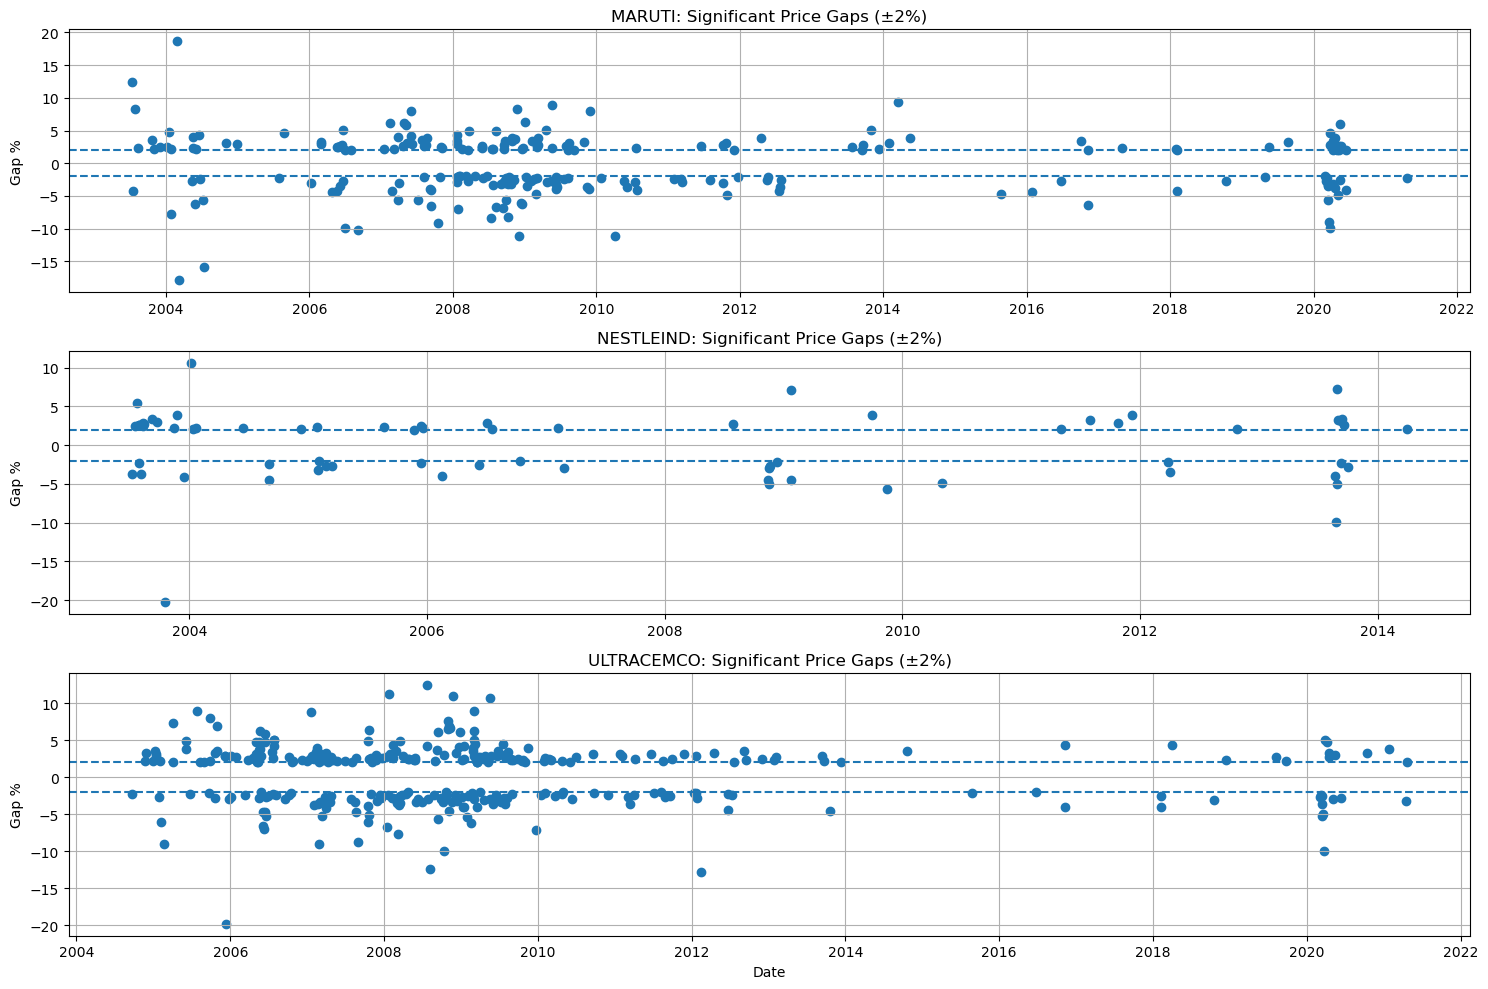

In [51]:
plt.figure(figsize=(15,10))

# ---------- MARUTI ----------
plt.subplot(3, 1, 1)
plt.scatter(gap_days_M['Date'], gap_days_M['Gap_Percent'], marker='o')
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')
plt.title('MARUTI: Significant Price Gaps (±2%)')
plt.ylabel('Gap %')
plt.grid(True)

# ---------- NESTLE ----------
plt.subplot(3, 1, 2)
plt.scatter(gap_days_N['Date'], gap_days_N['Gap_Percent'], marker='o')
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')
plt.title('NESTLEIND: Significant Price Gaps (±2%)')
plt.ylabel('Gap %')
plt.grid(True)

# ---------- ULTRACEMCO ----------
plt.subplot(3, 1, 3)
plt.scatter(gap_days_U['Date'], gap_days_U['Gap_Percent'], marker='o')
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')
plt.title('ULTRACEMCO: Significant Price Gaps (±2%)')
plt.xlabel('Date')
plt.ylabel('Gap %')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Observations
# MARUTI shows the highest frequency and magnitude of price gaps
# NESTLEIND has fewer gaps, indicating a more stable, defensive stock
# ULTRACEMCO gaps often align with infrastructure and macroeconomic news

# 📈 Volume Insight
# Most gap days coincide with unusually high trading volume
# Confirms strong market reaction to overnight information

In [52]:
#COMPARARATIVE ANALYSIS
Maruti = Maruti.sort_values('Date').reset_index(drop=True)
Ultracemco = Ultracemco.sort_values('Date').reset_index(drop=True)
Nestle_india = Nestle_india.sort_values('Date').reset_index(drop=True)

#: Calculate Percentage Change for Each Company
maruti_pct_change = (
    (Maruti['Close'].iloc[-1] - Maruti['Close'].iloc[0]) /
    Maruti['Close'].iloc[0]
) * 100

ultra_pct_change = (
    (Ultracemco['Close'].iloc[-1] - Ultracemco['Close'].iloc[0]) /
    Ultracemco['Close'].iloc[0]
) * 100

nestle_pct_change = (
    (Nestle_india['Close'].iloc[-1] - Nestle_india['Close'].iloc[0]) /
    Nestle_india['Close'].iloc[0]
) * 100

percentage_change_df = pd.DataFrame({
    'Stock': ['MARUTI', 'ULTRACEMCO', 'NESTLEIND'],
    'Percentage Change (%)': [
        maruti_pct_change,
        ultra_pct_change,
        nestle_pct_change
    ]
})

percentage_change_df


,Stock,Percentage Change (%)
0,MARUTI,3829.184419
1,ULTRACEMCO,2313.124520
2,NESTLEIND,553.769066


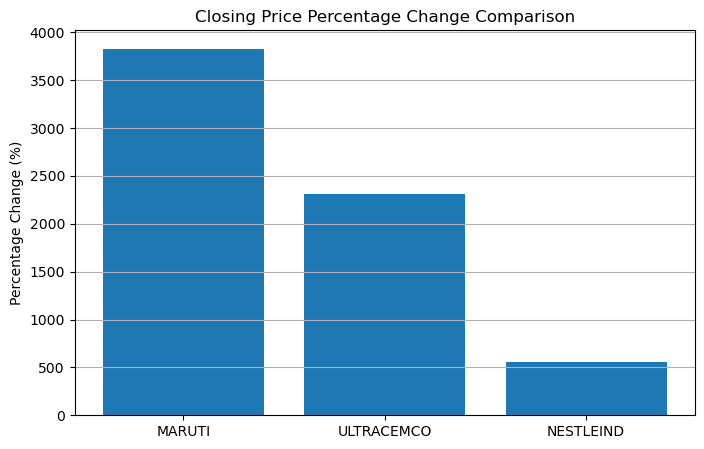

In [53]:
plt.figure(figsize=(8,5))
plt.bar(
    percentage_change_df['Stock'],
    percentage_change_df['Percentage Change (%)']
)
plt.ylabel('Percentage Change (%)')
plt.title('Closing Price Percentage Change Comparison')
plt.grid(True, axis='y')
plt.show()


In [ ]:
# Observations
# The stock with the highest percentage change shows the strongest long-term price appreciation
# A higher percentage change indicates better capital growth, but not necessarily lower risk

# Among the three stocks, the one with the greatest percentage change demonstrated the strongest long-term growth, 
# indicating higher return potential, though this may come with increased volatility.

In [55]:
#calculating CAGR
def calculate_cagr(df):
    df = df.sort_values('Date')
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]
    
    years = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days / 365.25
    cagr = (end_price / start_price) ** (1 / years) - 1
    return cagr

#Maximum Drawdown
def calculate_max_drawdown(df):
    df = df.sort_values('Date')
    cumulative_max = df['Close'].cummax()
    drawdown = (df['Close'] - cumulative_max) / cumulative_max
    return drawdown.min()

#Volatality
def calculate_volatility(df):
    df = df.sort_values('Date')
    daily_returns = df['Close'].pct_change()
    return daily_returns.std()



In [56]:
#calculating metrick for each stock
data = {
    'Stock': ['MARUTI', 'ULTRACEMCO', 'NESTLEIND'],
    'CAGR': [
        calculate_cagr(Maruti),
        calculate_cagr(Ultracemco),
        calculate_cagr(Nestle_india)
    ],
    'Max_Drawdown': [
        calculate_max_drawdown(Maruti),
        calculate_max_drawdown(Ultracemco),
        calculate_max_drawdown(Nestle_india)
    ],
    'Volatility': [
        calculate_volatility(Maruti),
        calculate_volatility(Ultracemco),
        calculate_volatility(Nestle_india)
    ]
}

metrics_df = pd.DataFrame(data)
metrics_df


,Stock,CAGR,Max_Drawdown,Volatility
0,MARUTI,0.228906,-0.613397,0.021721
1,ULTRACEMCO,0.210263,-0.777797,0.020955
2,NESTLEIND,0.181635,-0.324011,0.015261


In [58]:
# Normalize CAGR (higher is better)
metrics_df['CAGR_norm'] = (
    (metrics_df['CAGR'] - metrics_df['CAGR'].min()) /
    (metrics_df['CAGR'].max() - metrics_df['CAGR'].min())
)

# Normalize Drawdown (lower is better)
metrics_df['Drawdown_norm'] = (
    (metrics_df['Max_Drawdown'].max() - metrics_df['Max_Drawdown']) /
    (metrics_df['Max_Drawdown'].max() - metrics_df['Max_Drawdown'].min())
)

# Normalize Volatility (lower is better)
metrics_df['Volatility_norm'] = (
    (metrics_df['Volatility'].max() - metrics_df['Volatility']) /
    (metrics_df['Volatility'].max() - metrics_df['Volatility'].min())
)

# Weightage used (Balanced Investor):
# CAGR → 50%
# Drawdown → 30%
# Volatility → 20%

metrics_df['Investment_Score'] = (
    0.5 * metrics_df['CAGR_norm'] +
    0.3 * metrics_df['Drawdown_norm'] +
    0.2 * metrics_df['Volatility_norm']
)

metrics_df.sort_values('Investment_Score', ascending=False)


,Stock,CAGR,Max_Drawdown,Volatility,CAGR_norm,Drawdown_norm,Volatility_norm,Investment_Score
0,MARUTI,0.228906,-0.613397,0.021721,1.000000,0.637714,0.000000,0.691314
1,ULTRACEMCO,0.210263,-0.777797,0.020955,0.605625,1.000000,0.118573,0.626527
2,NESTLEIND,0.181635,-0.324011,0.015261,0.000000,0.000000,1.000000,0.200000


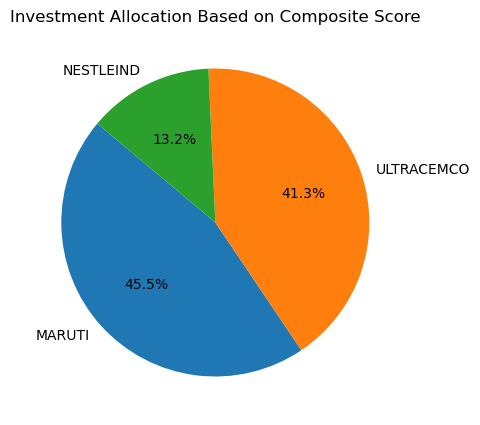

In [62]:
plt.figure(figsize=(5,5))

plt.pie(
    metrics_df['Investment_Score'],
    labels=metrics_df['Stock'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Investment Allocation Based on Composite Score')
plt.show()


In [59]:
# The stock with the highest composite score is the best investment choice as it offers the most favorable balance between 
# return and risk.
best_stock = metrics_df.loc[
    metrics_df['Investment_Score'].idxmax(), 'Stock'
]

best_stock


'MARUTI'

In [ ]:
#  The stock with the highest composite score is the best investment choice as it offers the most favorable balance between 
# return and risk is MARUTU